In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import idx2numpy

In [ ]:
train_images = idx2numpy.convert_from_file('../MNIST/train-images.idx3-ubyte')
train_labels = idx2numpy.convert_from_file('../MNIST/train-labels.idx1-ubyte')
test_images  = idx2numpy.convert_from_file('../MNIST/t10k-images.idx3-ubyte')
test_labels  = idx2numpy.convert_from_file('../MNIST/t10k-labels.idx1-ubyte')

def select_balanced_samples(images, labels, per_class):
    selected_idx = []
    for digit in range(10):
        idx = np.where(labels == digit)[0]
        chosen = np.random.choice(idx, per_class, replace=False)
        selected_idx.extend(chosen)
    selected_idx = np.array(selected_idx)
    np.random.shuffle(selected_idx)
    return images[selected_idx], labels[selected_idx]

np.random.seed(42)
X_train, y_train = select_balanced_samples(train_images, train_labels, 500)
X_test,  y_test  = select_balanced_samples(test_images,  test_labels,  100)

X_train = X_train.reshape(-1, 784).astype(np.float64) / 255.0
X_test  = X_test.reshape(-1, 784).astype(np.float64)  / 255.0

def one_hot_encode(labels, num_classes=10):
    encoded = np.zeros((len(labels), num_classes))
    for i, l in enumerate(labels):
        encoded[i, l] = 1.0
    return encoded

Y_train = one_hot_encode(y_train)
Y_test  = one_hot_encode(y_test)

print(f"Training samples: {X_train.shape[0]}  |  Test samples: {X_test.shape[0]}")
print(f"Input dim: {X_train.shape[1]}  |  Output dim: {Y_train.shape[1]}")

Training samples: 5000  |  Test samples: 1000
Input dim: 784  |  Output dim: 10


In [ ]:
def tanh(z):
    return np.tanh(z)

def tanh_derivative(a):
    return 1.0 - a ** 2

def softmax(z):
    z_shifted = z - np.max(z)
    exp_z = np.exp(z_shifted)
    return exp_z / np.sum(exp_z)

n_input  = 784
n_hidden = 1000
n_output = 10

scale1 = np.sqrt(2.0 / (n_input + n_hidden))
W1 = np.random.randn(n_hidden, n_input) * scale1
b1 = np.zeros((n_hidden, 1))

scale2 = np.sqrt(2.0 / (n_hidden + n_output))
W2 = np.random.randn(n_output, n_hidden) * scale2
b2 = np.zeros((n_output, 1))

learning_rate = 0.005
epochs = 10

train_losses = []
train_accuracies = []
test_accuracies = []

for epoch in range(epochs):
    epoch_loss = 0.0
    correct = 0

    perm = np.random.permutation(X_train.shape[0])

    for i in perm:
        x = X_train[i].reshape(-1, 1)
        y = Y_train[i].reshape(-1, 1)

        z1 = W1 @ x + b1
        a1 = tanh(z1)

        z2 = W2 @ a1 + b2
        a2 = softmax(z2)

        loss = -np.sum(y * np.log(a2 + 1e-12))
        epoch_loss += loss

        if np.argmax(a2) == np.argmax(y):
            correct += 1

        dL_dz2 = a2 - y
        dL_dW2 = dL_dz2 @ a1.T
        dL_db2 = dL_dz2

        dL_da1 = W2.T @ dL_dz2
        dL_dz1 = dL_da1 * tanh_derivative(a1)
        dL_dW1 = dL_dz1 @ x.T
        dL_db1 = dL_dz1

        W2 -= learning_rate * dL_dW2
        b2 -= learning_rate * dL_db2
        W1 -= learning_rate * dL_dW1
        b1 -= learning_rate * dL_db1

    avg_loss  = epoch_loss / X_train.shape[0]
    train_acc = correct / X_train.shape[0] * 100
    train_losses.append(avg_loss)
    train_accuracies.append(train_acc)

    test_correct = 0
    for i in range(X_test.shape[0]):
        x = X_test[i].reshape(-1, 1)
        z1 = W1 @ x + b1
        a1 = tanh(z1)
        z2 = W2 @ a1 + b2
        a2 = softmax(z2)
        if np.argmax(a2) == y_test[i]:
            test_correct += 1
    test_acc = test_correct / X_test.shape[0] * 100
    test_accuracies.append(test_acc)

    print(f"Epoch {epoch+1:2d}/{epochs} | Loss: {avg_loss:.4f} | Train Acc: {train_acc:.2f}% | Test Acc: {test_acc:.2f}%")

Epoch  1/10 | Loss: 0.5444 | Train Acc: 83.88% | Test Acc: 88.40%
Epoch  2/10 | Loss: 0.3407 | Train Acc: 89.68% | Test Acc: 90.20%
Epoch  3/10 | Loss: 0.2959 | Train Acc: 91.06% | Test Acc: 89.90%
Epoch  4/10 | Loss: 0.2659 | Train Acc: 91.90% | Test Acc: 89.00%
Epoch  5/10 | Loss: 0.2419 | Train Acc: 92.76% | Test Acc: 89.50%
Epoch  6/10 | Loss: 0.2250 | Train Acc: 93.08% | Test Acc: 90.20%
Epoch  7/10 | Loss: 0.2058 | Train Acc: 93.84% | Test Acc: 88.10%
Epoch  8/10 | Loss: 0.1905 | Train Acc: 94.02% | Test Acc: 89.20%
Epoch  9/10 | Loss: 0.1778 | Train Acc: 94.78% | Test Acc: 91.50%
Epoch 10/10 | Loss: 0.1570 | Train Acc: 95.16% | Test Acc: 89.30%


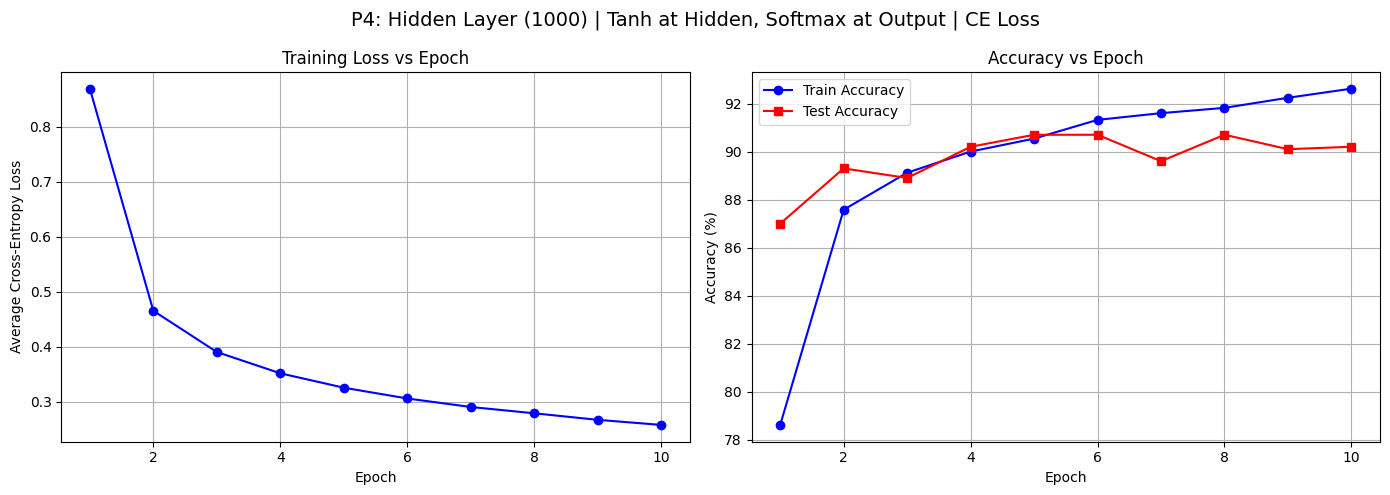


Final Train Accuracy: 92.62%
Final Test Accuracy:  90.20%


In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(range(1, epochs+1), train_losses, 'b-o')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Average Cross-Entropy Loss')
ax1.set_title('Training Loss vs Epoch')
ax1.grid(True)

ax2.plot(range(1, epochs+1), train_accuracies, 'b-o', label='Train Accuracy')
ax2.plot(range(1, epochs+1), test_accuracies,  'r-s', label='Test Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Accuracy vs Epoch')
ax2.legend()
ax2.grid(True)

plt.suptitle('P4: Hidden Layer (1000) | Tanh at Hidden, Softmax at Output | CE Loss', fontsize=14)
plt.tight_layout()
plt.show()

print(f"\nFinal Train Accuracy: {train_accuracies[-1]:.2f}%")
print(f"Final Test Accuracy:  {test_accuracies[-1]:.2f}%")